<a href="https://colab.research.google.com/github/sahanapatil2209/data-science-projects/blob/main/customer-segmentation/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Developed a customer segmentation system using RFM based feature engineering and multiple unsupervised learning techniques. Processed raw transaction level data to derive behavioral metrics such as recency, frequency, and monetary value, followed by log transformation and feature scaling to handle skewness and ensure balanced clustering.

Implemented and compared K Means, Hierarchical Clustering, DBSCAN, and Gaussian Mixture Models to segment customers into distinct behavioral groups. Evaluated clustering performance using silhouette score and interpreted segments to generate actionable business insights including identification of high value customers, churn risk segments, and growth opportunities.

The project demonstrates the ability to bridge data science techniques with real world business applications in marketing and customer lifecycle management.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

**Load and clean data**

In [ ]:
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")
print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo   

In [ ]:
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Amount"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

**Create RFM table**

In [ ]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Amount": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


**Log transform**

In [ ]:
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].copy()
rfm_log = np.log1p(rfm_log)

**Scale data**

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [ ]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(rfm_pca, columns=["PC1", "PC2"])

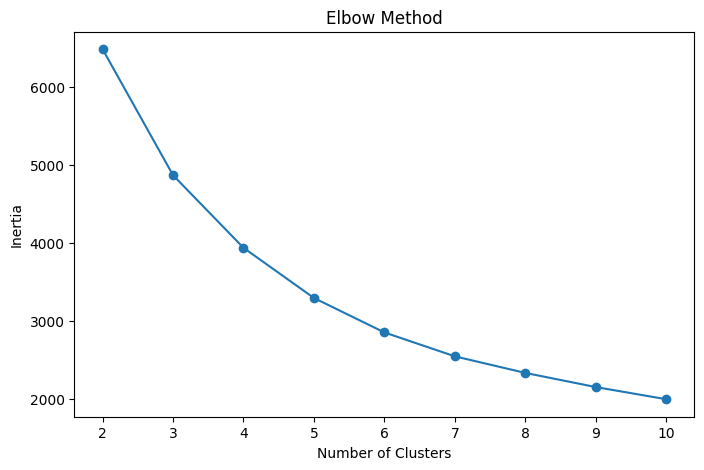

In [ ]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"k={k}, silhouette_score={score:.3f}")

k=2, silhouette_score=0.433
k=3, silhouette_score=0.337
k=4, silhouette_score=0.337
k=5, silhouette_score=0.316
k=6, silhouette_score=0.313
k=7, silhouette_score=0.310
k=8, silhouette_score=0.301
k=9, silhouette_score=0.282
k=10, silhouette_score=0.279


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [ ]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0          18.12       2.15    551.82
1          12.13      13.71   8074.27
2          71.08       4.08   1802.83
3         182.50       1.32    343.45


**Use PCA for visualization**

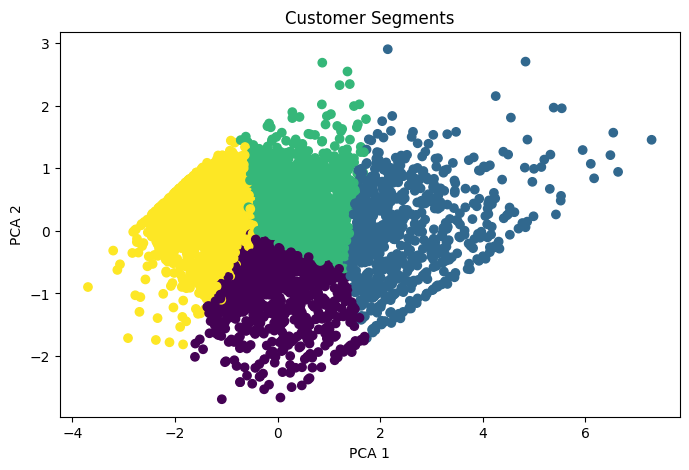

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(rfm_pca[:, 0], rfm_pca[:, 1], c=rfm["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments")
plt.show()

**Find best k using elbow method**

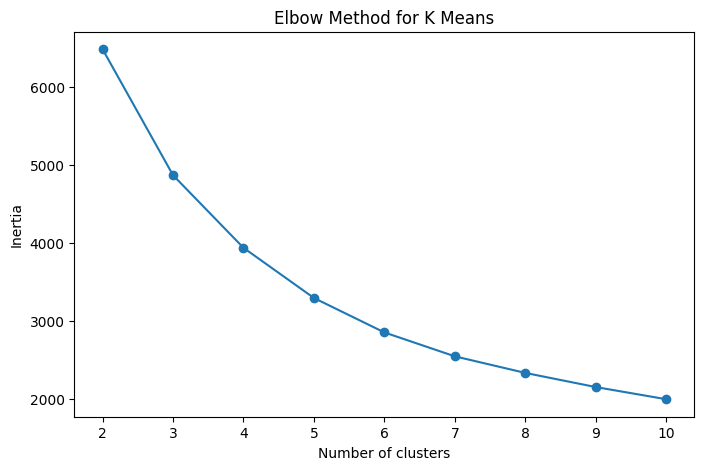

In [ ]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K Means")
plt.show()

**Check silhouette scores**

In [ ]:
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"KMeans k={k}, silhouette score={score:.3f}")

KMeans k=2, silhouette score=0.433
KMeans k=3, silhouette score=0.337
KMeans k=4, silhouette score=0.337
KMeans k=5, silhouette score=0.316
KMeans k=6, silhouette score=0.313
KMeans k=7, silhouette score=0.310
KMeans k=8, silhouette score=0.301
KMeans k=9, silhouette score=0.282
KMeans k=10, silhouette score=0.279


The optimal number of clusters is 5 because the inertia shows significant reduction up to k = 5, after which the rate of improvement slows down considerably, indicating diminishing returns from adding more clusters while increasing model complexity.

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm["KMeans_Cluster"] = kmeans.fit_predict(rfm_scaled)

In [ ]:
hc = AgglomerativeClustering(n_clusters=4, linkage="ward")
rfm["Hierarchical_Cluster"] = hc.fit_predict(rfm_scaled)

In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=10)
rfm["DBSCAN_Cluster"] = dbscan.fit_predict(rfm_scaled)

In [ ]:
gmm = GaussianMixture(n_components=4, random_state=42)
rfm["GMM_Cluster"] = gmm.fit_predict(rfm_scaled)

In [ ]:
models = {
    "KMeans": rfm["KMeans_Cluster"],
    "Hierarchical": rfm["Hierarchical_Cluster"],
    "GMM": rfm["GMM_Cluster"]
}

for name, labels in models.items():
    score = silhouette_score(rfm_scaled, labels)
    print(f"{name} silhouette score = {score:.3f}")

KMeans silhouette score = 0.316
Hierarchical silhouette score = 0.242
GMM silhouette score = 0.174


In [ ]:
db_labels = rfm["DBSCAN_Cluster"]
valid_mask = db_labels != -1

if len(set(db_labels[valid_mask])) > 1:
    score = silhouette_score(rfm_scaled[valid_mask], db_labels[valid_mask])
    print(f"DBSCAN silhouette score = {score:.3f}")
else:
    print("DBSCAN did not form enough clusters for silhouette score.")

DBSCAN did not form enough clusters for silhouette score.


**K Means Clusters**

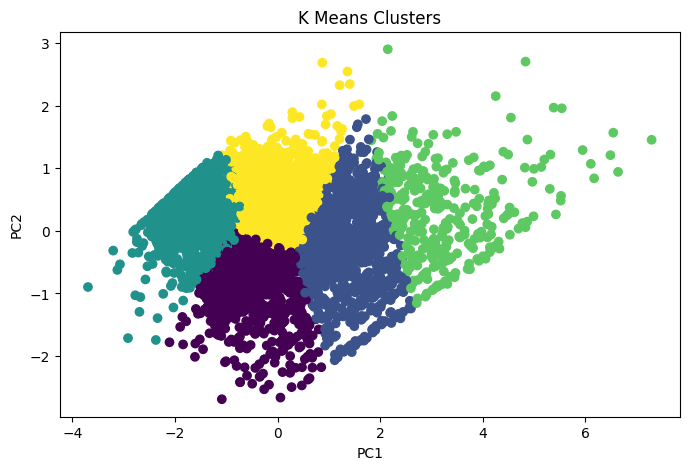

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=rfm["KMeans_Cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K Means Clusters")
plt.show()

**Hierarchical clusters**

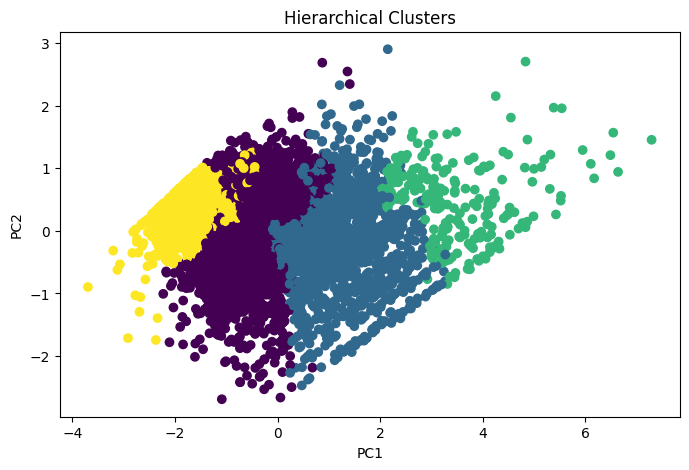

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=rfm["Hierarchical_Cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clusters")
plt.show()

**DBSCAN clusters**

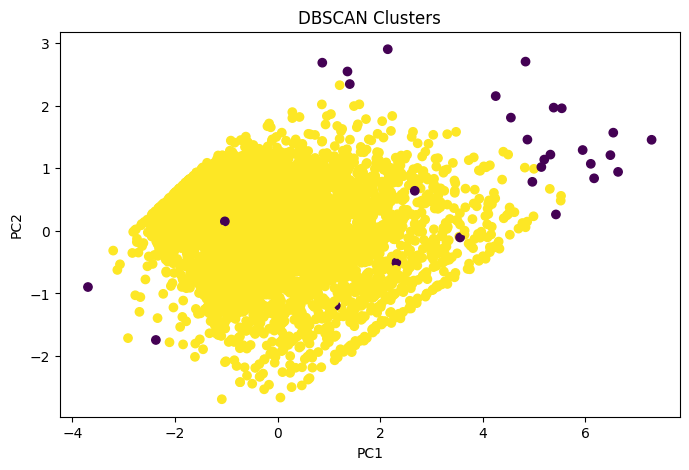

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=rfm["DBSCAN_Cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters")
plt.show()

**GMM Clusters**

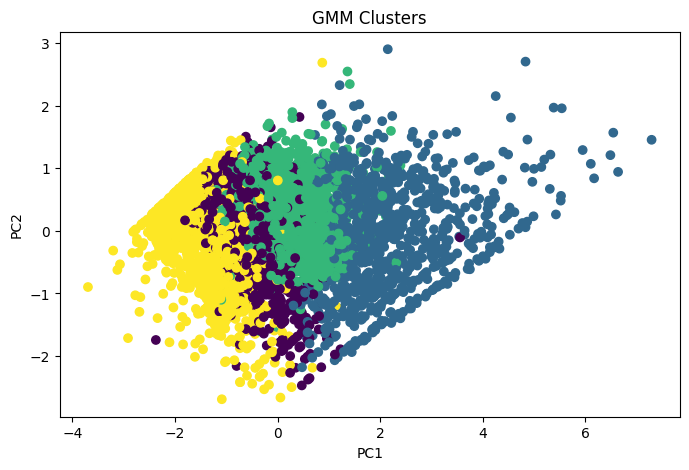

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=rfm["GMM_Cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters")
plt.show()

**K Means Profile**

In [ ]:
kmeans_profile = rfm.groupby("KMeans_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
print(kmeans_profile)

                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 27.99       1.61    389.04
1                 18.55       5.80   2168.93
2                211.15       1.21    277.20
3                 12.19      20.63  13780.08
4                104.14       3.13   1455.97


**Hierarchial Profile**

In [ ]:
hier_profile = rfm.groupby("Hierarchical_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
print(hier_profile)

                      Recency  Frequency  Monetary
Hierarchical_Cluster                              
0                       79.95       2.08    804.53
1                       23.13       5.64   2190.55
2                       10.59      24.31  17458.93
3                      243.21       1.27    256.79


**DBScan Profile**

In [ ]:
dbscan_profile = rfm[rfm["DBSCAN_Cluster"] != -1].groupby("DBSCAN_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
print(dbscan_profile)

                Recency  Frequency  Monetary
DBSCAN_Cluster                              
0                 92.75       3.94   1587.89


**GMM Profile**

In [ ]:
gmm_profile = rfm.groupby("GMM_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
print(gmm_profile)

             Recency  Frequency  Monetary
GMM_Cluster                              
0              93.97       2.00    886.12
1              17.35      11.97   6258.69
2              67.36       3.94   1619.00
3             156.68       1.00    412.80


K Means was selected as the final clustering model because it achieved the highest silhouette score of 0.316, indicating better cluster separation and cohesion compared to Hierarchical Clustering at 0.242 and Gaussian Mixture Model at 0.174. Among the clustering techniques tested, K Means was selected as the final model because it produced the most interpretable and business meaningful customer segments. It clearly separated high value loyal customers, active regular customers, at risk customers, low value occasional buyers, and inactive customers, making it the most useful model for targeted retention and marketing strategies.